# 14 — LLM Stance Predictions: Agreement & Time Series (6 models)

Six models — **DeepSeek V3, Gemini 2.5 Flash, GPT-4o Mini, Llama 3.3, Mistral Large, Qwen 2.5 72B** — each classified every turn from Fed, BoE, and ECB press conferences into a 5-class monetary-policy stance (dovish / mostly dovish / neutral / mostly hawkish / hawkish) plus a confidence rating.

This is the **descriptive / statistical** companion to `multihead_turns_colab.ipynb` (which does the mechanistic DeBERTa / swap / attribution work). It runs locally, no GPU.

**Contents**
1. **Agreement** — overall (exact + Fleiss κ), pairwise (Cohen κ, 15 pairs + heatmap), by bank, by speaker role
2. **Stanced vs. direction** — hierarchical κ: do models disagree on *whether* a turn is stanced, or on *which way*?
3. **Class balance** — label distribution by model, by bank; per-model leniency (neutral-rate) ranking
4. **Agreement vs. confidence** — do models agree more on turns they rate high-confidence?
5. **Hawk score over time** — mean stance per meeting per model, per bank
6. **Disagreement over time** — three measures: binary, label entropy, score dispersion (SD)
7. **Confidence over time** — mean confidence per meeting per model
8. **Ensemble stance series** — mean-of-6 stance per meeting + dispersion band, exported for the spillover VAR

In [18]:
from itertools import combinations
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import entropy, spearmanr

pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid", font_scale=0.95)

In [19]:
ROOT = Path("..")
OUTPUT_DIR = ROOT / "output" / "stance"

INPUT_FILES = {
    "deepseekv3":      ROOT / "output/stance/turn_predictions_deepseekv3.csv",
    "gemini25flash":   ROOT / "output/stance/turn_predictions_gemini25flash.csv",
    "gpt-4o":          ROOT / "output/stance/turn_predictions_gpt-4o.csv",
    "llama33":         ROOT / "output/stance/turn_predictions_llama33.csv",
    "mistrallarge_or": ROOT / "output/stance/turn_predictions_mistrallarge_or.csv",
    "qwen25_72b":      ROOT / "output/stance/turn_predictions_qwen25_72b.csv",
}
MODELS = list(INPUT_FILES.keys())
BANKS  = ["BoE", "ECB", "Fed"]

# Display labels (from src/llm/openrouter_models.py)
MODEL_LABELS = {
    "deepseekv3":      "DeepSeek V3",
    "gemini25flash":   "Gemini 2.5 Flash",
    "gpt-4o":          "GPT-4o Mini",
    "llama33":         "Llama 3.3",
    "mistrallarge_or": "Mistral Large",
    "qwen25_72b":      "Qwen 2.5 72B",
}

LABEL_ORDER = ["dovish", "mostly dovish", "neutral", "mostly hawkish", "hawkish"]
LABEL_SCORE = {"dovish": -2, "mostly dovish": -1, "neutral": 0, "mostly hawkish": 1, "hawkish": 2}
CONF_SCORE  = {"low": 1, "medium": 2, "high": 3}
STANCED     = {"dovish", "mostly dovish", "mostly hawkish", "hawkish"}

_palette = sns.color_palette("tab10", len(MODELS))
MODEL_COLORS = {m: _palette[i] for i, m in enumerate(MODELS)}
BANK_TITLES = {"BoE": "Bank of England", "ECB": "European Central Bank", "Fed": "Federal Reserve"}

In [20]:
# Health check — completeness & parse_errors per model file (warns; does not hard-fail)
hc_rows = []
for key, path in INPUT_FILES.items():
    if not path.exists():
        hc_rows.append({"model": MODEL_LABELS[key], "status": "MISSING", "rows": 0,
                        "labeled": 0, "parse_error": 0, "neutral_rate": "—"})
        continue
    d = pd.read_csv(path)
    lab = d["label"].astype(str).str.strip().str.lower()
    hc_rows.append({
        "model":        MODEL_LABELS[key],
        "status":       "ok",
        "rows":         len(d),
        "labeled":      int(lab.ne("nan").sum()),
        "parse_error":  int((lab == "parse_error").sum()),
        "neutral_rate": f"{(lab == 'neutral').mean():.1%}",
    })

hc = pd.DataFrame(hc_rows).set_index("model")
print(hc.to_string())

_incomplete = [r["model"] for r in hc_rows if r["status"] != "ok" or r["labeled"] < r["rows"]]
_haspe      = [r["model"] for r in hc_rows if r["parse_error"] > 0]
if _incomplete:
    print(f"\nWARNING: Incomplete/missing: {_incomplete} — agreement metrics will be biased for these.")
if _haspe:
    print(f"WARNING: parse_error rows present in: {_haspe} — excluded from metrics, but check scoring.")
if not _incomplete and not _haspe:
    print("\nOK: All 6 model files complete and clean.")

                 status  rows  labeled  parse_error neutral_rate
model                                                           
DeepSeek V3          ok  3972     3972            0        84.7%
Gemini 2.5 Flash     ok  3972     3972            0        70.6%
GPT-4o Mini          ok  3972     3972            0        73.9%
Llama 3.3            ok  3972     3972            0        69.8%
Mistral Large        ok  3972     3972            0        73.4%
Qwen 2.5 72B         ok  3972     3972            0        83.9%

OK: All 6 model files complete and clean.


## 0. Load Data

In [21]:
frames = []
for path in INPUT_FILES.values():
    frames.append(pd.read_csv(path))
raw = pd.concat(frames, ignore_index=True)

raw["label"]      = raw["label"].str.strip().str.lower()
raw["confidence"] = raw["confidence"].str.strip().str.lower()

# Date column is a mix of YYYYMM (BoE) and YYYYMMDD (ECB/Fed) integers;
# truncate to first 6 chars for uniform month-level grouping.
raw["date_dt"]    = pd.to_datetime(raw["date"].astype(str).str[:6], format="%Y%m")

raw["hawk_score"] = raw["label"].map(LABEL_SCORE)    # parse_errors → NaN, excluded from means
raw["conf_score"] = raw["confidence"].map(CONF_SCORE)

# Deduplicate in case a turn was scored twice by the same model
raw = raw.drop_duplicates(subset=["turn_uid", "model_key"], keep="first")

n_parse_err = (raw["label"] == "parse_error").sum()
print(f"Models:              {len(MODELS)}  ({', '.join(MODELS)})")
print(f"Rows (after dedup):  {len(raw):,}")
print(f"Unique turns:        {raw['turn_uid'].nunique():,}")
print(f"Banks:               {sorted(raw['bank'].unique())}")
print(f"Labels:              {sorted(raw['label'].unique())}")
print(f"Confidence:          {sorted(raw['confidence'].dropna().unique())}")
print(f"Date range:          {raw['date_dt'].min().date()} – {raw['date_dt'].max().date()}")
print(f"Parse errors:        {n_parse_err} rows (excluded from all metrics)")

Models:              6  (deepseekv3, gemini25flash, gpt-4o, llama33, mistrallarge_or, qwen25_72b)
Rows (after dedup):  23,832
Unique turns:        3,972
Banks:               ['BoE', 'ECB', 'Fed']
Labels:              ['dovish', 'hawkish', 'mostly dovish', 'mostly hawkish', 'neutral']
Confidence:          ['high', 'low', 'medium']
Date range:          2015-01-01 – 2026-02-01
Parse errors:        0 rows (excluded from all metrics)


In [22]:
# Pivot wide: one row per turn, one column per model
meta = (
    raw[raw["model_key"] == MODELS[0]]
    [["turn_uid", "bank", "date_dt", "speaker", "speaker_role", "text"]]
    .copy()
)

label_wide = (
    raw.pivot_table(index="turn_uid", columns="model_key", values="label", aggfunc="first")
    .reset_index()
)
label_wide.columns.name = None

conf_wide = (
    raw.pivot_table(index="turn_uid", columns="model_key", values="confidence", aggfunc="first")
    .reset_index()
    .rename(columns={m: f"{m}_conf" for m in MODELS})
)
conf_wide.columns.name = None

wide = meta.merge(label_wide, on="turn_uid").merge(conf_wide, on="turn_uid")

# Mask parse_errors so they don't contaminate agreement calculations
for m in MODELS:
    wide.loc[wide[m] == "parse_error", m] = pd.NA

# ── Derived per-turn columns (shared with multihead_turns_colab.ipynb) ──
for m in MODELS:
    wide[f"{m}_score"]   = wide[m].map(LABEL_SCORE)
    wide[f"{m}_stanced"] = wide[m].isin(STANCED)

score_cols = [f"{m}_score" for m in MODELS]
wide["all_agree"]      = wide[MODELS].nunique(axis=1, dropna=False) == 1
wide["disagree_width"] = wide[score_cols].max(axis=1) - wide[score_cols].min(axis=1)
wide["mean_score"]     = wide[score_cols].mean(axis=1)
wide["score_std"]      = wide[score_cols].std(axis=1, ddof=0)          # population SD
wide["mean_pair_d"]    = wide[score_cols].apply(
    lambda r: np.mean([abs(a - b) for a, b in combinations(r.values, 2)]), axis=1)

def _label_entropy(row):
    labs = [row[m] for m in MODELS]
    counts = [labs.count(l) for l in LABEL_ORDER]
    return entropy(counts, base=5) if sum(counts) else np.nan
wide["label_entropy"]  = wide.apply(_label_entropy, axis=1)
wide["n_stanced"]      = wide[[f"{m}_stanced" for m in MODELS]].sum(axis=1)

print(f"Wide table shape: {wide.shape}  (≈ {len(raw)//len(MODELS):,} turns × {len(wide.columns)} cols)")
print(f"Turns with any NaN label: {wide[MODELS].isna().any(axis=1).sum()}")
wide.head(3)

Wide table shape: (3972, 37)  (≈ 3,972 turns × 37 cols)
Turns with any NaN label: 0


,turn_uid,bank,date_dt,speaker,speaker_role,text,deepseekv3,gemini25flash,gpt-4o,llama33,...,mistrallarge_or_stanced,qwen25_72b_score,qwen25_72b_stanced,all_agree,disagree_width,mean_score,score_std,mean_pair_d,label_entropy,n_stanced
0,BoE_201502_transcript_1,BoE,2015-02-01,Mark Carney,governor,"Well, recognising that this is a hypothetical question, you know, would a change in Greece's position have an impact...",neutral,neutral,neutral,neutral,...,False,0,False,True,0,0.0,0.0,0.0,0.0,0
1,BoE_201502_transcript_3,BoE,2015-02-01,Mark Carney,governor,"Well, as you know, Jennifer, we don't do real time updating of our inflation forecast. The next one's due in the mid...",neutral,neutral,neutral,neutral,...,False,0,False,True,0,0.0,0.0,0.0,0.0,0
2,BoE_201502_transcript_5,BoE,2015-02-01,Mark Carney,governor,"Look - markets will - I think - let me go back to something I said at my opening remarks, which is that what markets...",mostly hawkish,mostly hawkish,mostly hawkish,mostly hawkish,...,True,1,True,True,0,1.0,0.0,0.0,0.0,6


## 1. Agreement / Disagreement

Overall exact agreement and Fleiss' kappa; pairwise Cohen's kappa across all 15 model pairs (table + heatmap); breakdowns by bank and speaker role.

In [23]:
# Agreement helper functions (ported from notebooks/labeling_agreement.ipynb)

def cohens_kappa(left: pd.Series, right: pd.Series) -> float:
    paired = pd.DataFrame({"left": left, "right": right}).dropna()
    if paired.empty:
        return float("nan")
    agreement = (paired["left"] == paired["right"]).mean()
    confusion  = pd.crosstab(paired["left"], paired["right"])
    total      = confusion.to_numpy().sum()
    row_probs  = confusion.sum(axis=1) / total
    col_probs  = confusion.sum(axis=0) / total
    expected   = row_probs.mul(col_probs, fill_value=0).sum()
    if expected == 1:
        return float("nan")
    return (agreement - expected) / (1 - expected)


def fleiss_kappa(df: pd.DataFrame, label_cols: list, categories: list) -> float:
    n_subjects = len(df)
    n_raters   = len(label_cols)
    counts     = pd.DataFrame({cat: (df[label_cols] == cat).sum(axis=1) for cat in categories})
    p_j        = counts.sum() / (n_subjects * n_raters)
    P_i        = ((counts ** 2).sum(axis=1) - n_raters) / (n_raters * (n_raters - 1))
    P_bar      = P_i.mean()
    P_e        = (p_j ** 2).sum()
    if P_e == 1:
        return float("nan")
    return (P_bar - P_e) / (1 - P_e)

In [24]:
# 1a. Overall and per-bank agreement
pct_exact = wide["all_agree"].mean()
fk_all    = fleiss_kappa(wide, MODELS, LABEL_ORDER)

print(f"=== Overall ({len(MODELS)} models, 5-class) ===")
print(f"  % exact {len(MODELS)}-way agreement : {pct_exact:.1%}")
print(f"  Fleiss' κ                  : {fk_all:.3f}")

bank_rows = []
for bank, grp in wide.groupby("bank"):
    bank_rows.append({
        "bank": bank,
        "n_turns": len(grp),
        "% exact agreement": grp["all_agree"].mean(),
        "Fleiss' κ": fleiss_kappa(grp, MODELS, LABEL_ORDER),
    })

bank_summary = pd.DataFrame(bank_rows).set_index("bank")
print("\n=== By bank ===")
bank_summary.style.format({"% exact agreement": "{:.1%}", "Fleiss' κ": "{:.3f}"})

=== Overall (6 models, 5-class) ===
  % exact 6-way agreement : 62.0%
  Fleiss' κ                  : 0.526

=== By bank ===


,n_turns,% exact agreement,Fleiss' κ
bank,,,
BoE,895,70.6%,0.528
ECB,1163,60.2%,0.519
Fed,1914,59.0%,0.524


In [25]:
# 1b. Pairwise metrics (15 pairs)
pairwise_rows = []
for m_a, m_b in combinations(MODELS, 2):
    pairwise_rows.append({
        "model_a": m_a,
        "model_b": m_b,
        "% agreement": (wide[m_a] == wide[m_b]).mean(),
        "Cohen's κ": cohens_kappa(wide[m_a], wide[m_b]),
    })

pairwise_df = (
    pd.DataFrame(pairwise_rows)
    .sort_values("Cohen's κ", ascending=False)
    .reset_index(drop=True)
)
pairwise_df.style.format({"% agreement": "{:.1%}", "Cohen's κ": "{:.3f}"})

,model_a,model_b,% agreement,Cohen's κ
0,llama33,mistrallarge_or,82.2%,0.611
1,gemini25flash,llama33,80.8%,0.601
2,gemini25flash,mistrallarge_or,80.9%,0.582
3,gpt-4o,llama33,80.2%,0.569
4,gemini25flash,gpt-4o,80.2%,0.565
5,mistrallarge_or,qwen25_72b,83.9%,0.562
6,gpt-4o,mistrallarge_or,80.8%,0.560
7,deepseekv3,qwen25_72b,86.1%,0.509
8,llama33,qwen25_72b,80.2%,0.503
9,deepseekv3,gpt-4o,81.4%,0.489


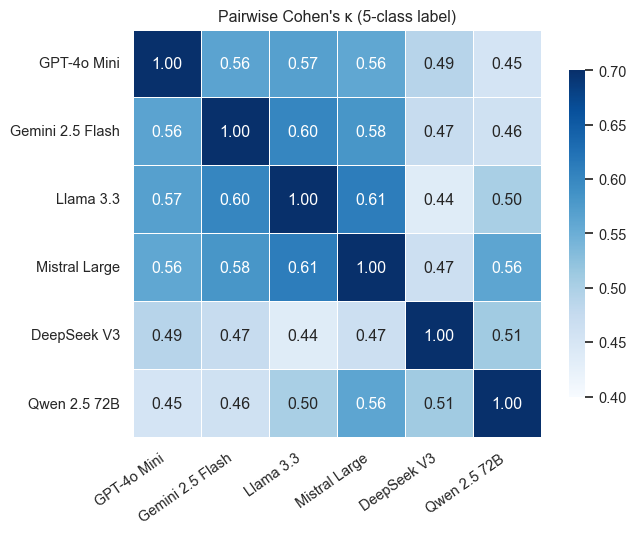

In [26]:
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

# build matrix
kappa_mat = pd.DataFrame(np.eye(len(MODELS)), index=MODELS, columns=MODELS)
for m_a, m_b in combinations(MODELS, 2):
    k = cohens_kappa(wide[m_a], wide[m_b])
    kappa_mat.loc[m_a, m_b] = k
    kappa_mat.loc[m_b, m_a] = k

# cluster order from 1 - kappa
dist_arr = (1 - kappa_mat).to_numpy(copy=True)
np.fill_diagonal(dist_arr, 0.0)

link = linkage(squareform(dist_arr), method="average")
order = kappa_mat.index[leaves_list(link)]

# reorder and relabel
disp = kappa_mat.loc[order, order].rename(index=MODEL_LABELS, columns=MODEL_LABELS)

# off-diagonal color scaling
off_diag = disp.where(~np.eye(len(disp), dtype=bool))
vmin = float(np.floor(off_diag.min().min() * 10) / 10)
vmax = float(np.ceil(off_diag.max().max() * 10) / 10)

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(
    disp,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=vmin,
    vmax=vmax,
    linewidths=0.4,
    linecolor="white",
    square=True,
    cbar_kws={"shrink": 0.8},
    ax=ax,
)

ax.set_title("Pairwise Cohen's κ (5-class label)")
plt.setp(ax.get_xticklabels(), rotation=35, ha="right")
plt.setp(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "llm_pairwise_kappa_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [27]:
# 1c. Pairwise kappa by bank
bybank_rows = []
for bank, grp in wide.groupby("bank"):
    for m_a, m_b in combinations(MODELS, 2):
        bybank_rows.append({
            "bank": bank,
            "pair": f"{MODEL_LABELS[m_a]} / {MODEL_LABELS[m_b]}",
            "% agreement": (grp[m_a] == grp[m_b]).mean(),
            "Cohen's k": cohens_kappa(grp[m_a], grp[m_b]),
        })

bybank_df = pd.DataFrame(bybank_rows)
bybank_pivot = bybank_df.pivot(index="pair", columns="bank", values="Cohen's k").round(3)
print("Cohen's kappa by pair x bank:")
bybank_pivot

Cohen's kappa by pair x bank:


bank,BoE,ECB,Fed
pair,,,
DeepSeek V3 / GPT-4o Mini,0.513,0.452,0.499
DeepSeek V3 / Gemini 2.5 Flash,0.415,0.493,0.473
DeepSeek V3 / Llama 3.3,0.354,0.460,0.442
DeepSeek V3 / Mistral Large,0.410,0.482,0.469
DeepSeek V3 / Qwen 2.5 72B,0.478,0.510,0.514
GPT-4o Mini / Llama 3.3,0.579,0.550,0.573
GPT-4o Mini / Mistral Large,0.567,0.520,0.577
GPT-4o Mini / Qwen 2.5 72B,0.497,0.425,0.451
Gemini 2.5 Flash / GPT-4o Mini,0.544,0.565,0.566


In [28]:
# 1d. Disagreement rate by bank and speaker_role
print("Disagreement rate by bank:")
print(
    wide.groupby("bank")["all_agree"]
    .apply(lambda s: 1 - s.mean())
    .rename("% disagree")
    .apply("{:.1%}".format)
)

if wide["speaker_role"].notna().any():
    print("\nDisagreement rate by speaker_role:")
    print(
        wide.groupby("speaker_role")["all_agree"]
        .apply(lambda s: 1 - s.mean())
        .rename("% disagree")
        .apply("{:.1%}".format)
    )

Disagreement rate by bank:
bank
BoE    29.4%
ECB    39.8%
Fed    41.0%
Name: % disagree, dtype: str

Disagreement rate by speaker_role:
speaker_role
chair        41.0%
governor     29.4%
president    39.8%
Name: % disagree, dtype: str


In [29]:
DOVE = {"dovish", "mostly dovish"}
HAWK = {"mostly hawkish", "hawkish"}
STANCED = DOVE | HAWK

label_df = wide[MODELS].copy()

has_dove = label_df.apply(lambda r: r.isin(DOVE).any(), axis=1)
has_hawk = label_df.apply(lambda r: r.isin(HAWK).any(), axis=1)
has_stanced = label_df.apply(lambda r: r.isin(STANCED).any(), axis=1)

conflict = has_dove & has_hawk
all_neutral = label_df.eq("neutral").all(axis=1)
all_agree = label_df.nunique(axis=1, dropna=False) == 1
all_agree_non_neutral = all_agree & (~all_neutral)

appendix_tbl = pd.DataFrame([
    {
        "Category": "All turns",
        "Turns": len(label_df),
        "Share of turns": 1.0,
    },
    {
        "Category": "At least one hawkish label",
        "Turns": int(has_hawk.sum()),
        "Share of turns": has_hawk.mean(),
    },
    {
        "Category": "At least one dovish label",
        "Turns": int(has_dove.sum()),
        "Share of turns": has_dove.mean(),
    },
    {
        "Category": "At least one stanced label",
        "Turns": int(has_stanced.sum()),
        "Share of turns": has_stanced.mean(),
    },
    {
        "Category": "At least one hawkish and one dovish label",
        "Turns": int(conflict.sum()),
        "Share of turns": conflict.mean(),
    },
    {
        "Category": "Unanimous neutral across all 6 models",
        "Turns": int(all_neutral.sum()),
        "Share of turns": all_neutral.mean(),
    },
    {
        "Category": "Unanimous non-neutral across all 6 models",
        "Turns": int(all_agree_non_neutral.sum()),
        "Share of turns": all_agree_non_neutral.mean(),
    },
])

appendix_tbl["Share of turns"] = appendix_tbl["Share of turns"].map(lambda x: f"{x:.1%}")

print(appendix_tbl.to_string(index=False))

                                 Category  Turns Share of turns
                                All turns   3972         100.0%
               At least one hawkish label    746          18.8%
                At least one dovish label   1023          25.8%
               At least one stanced label   1631          41.1%
At least one hawkish and one dovish label    138           3.5%
    Unanimous neutral across all 6 models   2341          58.9%
Unanimous non-neutral across all 6 models    120           3.0%


## 2. Stanced vs. Direction Agreement

Decompose disagreement hierarchically (after `notes/multihead_analysis_summary.md`):
- **kappa_stanced** — collapse to {neutral, stanced}: do models agree on *whether* a turn takes a stance?
- **kappa_direction** — among turns both models call directional, collapse to {dove, hawk}: do they agree on *which way*?

The signature finding: models agree near-perfectly on direction but only moderately on stancedness.

In [30]:
# 2. Hierarchical agreement — stancing vs direction
DOVE = {"dovish", "mostly dovish"}
HAWK = {"mostly hawkish", "hawkish"}

def to_stanced(s):
    return s.map(lambda x: np.nan if pd.isna(x) else ("stanced" if x in STANCED else "neutral"))
def to_direction(s):
    return s.map(lambda x: "dove" if x in DOVE else ("hawk" if x in HAWK else np.nan))

# κ_stanced: collapse to {neutral, stanced}
stanced_wide = wide.copy()
for m in MODELS:
    stanced_wide[m] = to_stanced(wide[m])
fk_stanced = fleiss_kappa(stanced_wide, MODELS, ["neutral", "stanced"])

rows = []
for m_a, m_b in combinations(MODELS, 2):
    k_st = cohens_kappa(to_stanced(wide[m_a]), to_stanced(wide[m_b]))
    # κ_direction: only on turns BOTH models call directional
    paired = pd.DataFrame({"a": to_direction(wide[m_a]), "b": to_direction(wide[m_b])}).dropna()
    k_dir   = cohens_kappa(paired["a"], paired["b"]) if len(paired) else np.nan
    agr_dir = (paired["a"] == paired["b"]).mean() if len(paired) else np.nan
    rows.append({"pair": f"{MODEL_LABELS[m_a]} / {MODEL_LABELS[m_b]}",
                 "κ_stanced": k_st, "κ_direction": k_dir,
                 "% dir agree": agr_dir, "n_both_dir": len(paired)})

hier = pd.DataFrame(rows)
print(f"Fleiss κ — stancing (neutral vs stanced), all {len(MODELS)} models: {fk_stanced:.3f}\n")
print(f"κ_stanced   range {hier['κ_stanced'].min():.3f}–{hier['κ_stanced'].max():.3f}  (mean {hier['κ_stanced'].mean():.3f})")
print(f"κ_direction range {hier['κ_direction'].min():.3f}–{hier['κ_direction'].max():.3f}  (mean {hier['κ_direction'].mean():.3f})")
print("\n→ Models agree on DIRECTION far more than on whether a turn is STANCED at all.")
hier.sort_values("κ_stanced").style.format(
    {"κ_stanced": "{:.3f}", "κ_direction": "{:.3f}", "% dir agree": "{:.1%}"})

Fleiss κ — stancing (neutral vs stanced), all 6 models: 0.616

κ_stanced   range 0.510–0.710  (mean 0.614)
κ_direction range 0.843–0.990  (mean 0.918)

→ Models agree on DIRECTION far more than on whether a turn is STANCED at all.


,pair,κ_stanced,κ_direction,% dir agree,n_both_dir
2,DeepSeek V3 / Llama 3.3,0.510,0.953,97.6%,551
0,DeepSeek V3 / Gemini 2.5 Flash,0.535,0.935,96.8%,558
3,DeepSeek V3 / Mistral Large,0.558,0.963,98.1%,536
1,DeepSeek V3 / GPT-4o Mini,0.559,0.939,97.0%,530
11,GPT-4o Mini / Qwen 2.5 72B,0.568,0.908,95.4%,548
13,Llama 3.3 / Qwen 2.5 72B,0.568,0.949,97.5%,605
8,Gemini 2.5 Flash / Qwen 2.5 72B,0.575,0.949,97.5%,599
14,Mistral Large / Qwen 2.5 72B,0.599,0.947,97.4%,576
4,DeepSeek V3 / Qwen 2.5 72B,0.631,0.990,99.5%,430
9,GPT-4o Mini / Llama 3.3,0.658,0.876,94.1%,842


In [31]:
LABEL_ORDER = ["dovish", "somewhat dovish", "neutral", "somewhat hawkish", "hawkish"]
HAWKISH = {"hawkish", "somewhat hawkish"}
DOVISH = {"dovish", "somewhat dovish"}

label_df = wide[MODELS].copy()
n_turns = len(label_df)
n_models = len(MODELS)

rows = []

for lab in LABEL_ORDER:
    any_lab = label_df.eq(lab).any(axis=1)
    all_lab = label_df.eq(lab).all(axis=1)
    mean_share = label_df.eq(lab).sum().sum() / (n_turns * n_models)

    rows.append({
        "Label": lab.title(),
        "Share of all model labels": mean_share,
        "Turns with >=1 such label": any_lab.mean(),
        "Turns with unanimous 6-model label": all_lab.mean(),
        "Unanimous turns (count)": int(all_lab.sum()),
    })

has_hawk = label_df.isin(HAWKISH).any(axis=1)
has_dove = label_df.isin(DOVISH).any(axis=1)
directional_conflict = has_hawk & has_dove

all_agree = label_df.nunique(axis=1, dropna=False) == 1
all_agree_neutral = label_df.eq("neutral").all(axis=1)

appendix_tbl = pd.DataFrame(rows)

summary_rows = pd.DataFrame([
    {
        "Label": "Any hawk-dove conflict",
        "Share of all model labels": np.nan,
        "Turns with >=1 such label": directional_conflict.mean(),
        "Turns with unanimous 6-model label": np.nan,
        "Unanimous turns (count)": int(directional_conflict.sum()),
    },
    {
        "Label": "Any 6-model agreement",
        "Share of all model labels": np.nan,
        "Turns with >=1 such label": all_agree.mean(),
        "Turns with unanimous 6-model label": np.nan,
        "Unanimous turns (count)": int(all_agree.sum()),
    },
    {
        "Label": "6-model agreement on neutral",
        "Share of all model labels": np.nan,
        "Turns with >=1 such label": all_agree_neutral.mean(),
        "Turns with unanimous 6-model label": np.nan,
        "Unanimous turns (count)": int(all_agree_neutral.sum()),
    },
])

appendix_tbl = pd.concat([appendix_tbl, summary_rows], ignore_index=True)

for col in ["Share of all model labels", "Turns with >=1 such label", "Turns with unanimous 6-model label"]:
    appendix_tbl[col] = appendix_tbl[col].map(lambda x: f"{x:.1%}" if pd.notnull(x) else "")

appendix_tbl

,Label,Share of all model labels,Turns with >=1 such label,Turns with unanimous 6-model label,Unanimous turns (count)
0,Dovish,3.3%,8.5%,0.4%,15
1,Somewhat Dovish,0.0%,0.0%,0.0%,0
2,Neutral,76.1%,90.3%,58.9%,2341
3,Somewhat Hawkish,0.0%,0.0%,0.0%,0
4,Hawkish,3.3%,6.5%,1.2%,46
5,Any hawk-dove conflict,,0.2%,,8
6,Any 6-model agreement,,62.0%,,2461
7,6-model agreement on neutral,,58.9%,,2341


## 3. Class Balance

Label distribution per model and per bank, plus a per-model leniency (neutral-rate) ranking.

In [32]:
# 1e. Label distribution per model
dist_rows = []
for model in MODELS:
    counts = wide[model].value_counts(normalize=True)
    dist_rows.append({"model": model, **{lbl: counts.get(lbl, 0.0) for lbl in LABEL_ORDER}})

dist_df = pd.DataFrame(dist_rows).set_index("model")[LABEL_ORDER]
print("Label distribution per model:")
dist_df.rename(index=MODEL_LABELS).style.format("{:.1%}").background_gradient(cmap="RdYlGn_r", axis=1)

Label distribution per model:


,dovish,somewhat dovish,neutral,somewhat hawkish,hawkish
model,,,,,
DeepSeek V3,2.5%,0.0%,84.7%,0.0%,4.5%
Gemini 2.5 Flash,4.6%,0.0%,70.6%,0.0%,5.2%
GPT-4o Mini,5.4%,0.0%,73.9%,0.0%,4.0%
Llama 3.3,4.5%,0.0%,69.8%,0.0%,2.6%
Mistral Large,1.7%,0.0%,73.4%,0.0%,1.7%
Qwen 2.5 72B,0.9%,0.0%,83.9%,0.0%,1.9%


In [33]:
# 3b. Label distribution by bank (pooled over models)  +  3c. leniency ranking
bank_dist = (
    raw[raw["label"].isin(LABEL_ORDER)]
    .groupby("bank")["label"].value_counts(normalize=True)
    .unstack()[LABEL_ORDER]
)
print("Label distribution by bank (pooled over models):")
display(bank_dist.style.format("{:.1%}").background_gradient(cmap="RdYlGn_r", axis=1))

# Leniency: neutral rate per model (most → least conservative)
leniency = dist_df["neutral"].sort_values(ascending=False).rename("neutral_rate").to_frame()
leniency["directional_rate"] = 1 - leniency["neutral_rate"]
leniency.index = [MODEL_LABELS[m] for m in leniency.index]
print("\nLeniency ranking (higher neutral_rate = more conservative):")
display(leniency.style.format("{:.1%}"))

# Stacked-bar visuals
stance_cmap = sns.color_palette("RdYlGn_r", 5)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
dist_df.rename(index=MODEL_LABELS).plot(kind="bar", stacked=True, ax=axes[0],
                                        color=stance_cmap, width=0.8)
axes[0].set_title("Label distribution by model"); axes[0].set_ylabel("share")
axes[0].legend(fontsize=7, loc="lower right", ncol=2)
bank_dist.plot(kind="bar", stacked=True, ax=axes[1], color=stance_cmap, width=0.6, legend=False)
axes[1].set_title("Label distribution by bank")
for ax in axes:
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "llm_class_balance.png", dpi=150, bbox_inches="tight")
plt.show()

KeyError: "['somewhat dovish', 'somewhat hawkish'] not in index"

In [ ]:
# 3d. Compact bank-level heterogeneity summary
# Table 1 uses unique turns for agreement; Tables 2 uses pooled model labels for stance mix.
bank_labels = raw[raw["label"].isin(LABEL_ORDER)].copy()
bank_labels["is_neutral"] = bank_labels["label"].eq("neutral")
bank_labels["is_hawkish"] = bank_labels["label"].isin(["mostly hawkish", "hawkish"])
bank_labels["is_dovish"] = bank_labels["label"].isin(["mostly dovish", "dovish"])

bank_turn_summary = (
    pd.DataFrame({
        "n_turns": wide.groupby("bank").size(),
        "exact_agreement": wide.groupby("bank")["all_agree"].mean(),
    })
    .join(
        bank_labels.groupby("bank").agg(
            neutral_share=("is_neutral", "mean"),
            directional_share=("is_neutral", lambda s: 1 - s.mean()),
        )
    )
    .loc[BANKS]
)

bank_hawkish_summary = (
    bank_labels.groupby("bank").agg(
        n_model_labels=("label", "size"),
        hawkish_share=("is_hawkish", "mean"),
        dovish_share=("is_dovish", "mean"),
    )
    .loc[BANKS]
)

print("Table 1. Turn-level heterogeneity summary:")
display(
    bank_turn_summary.style.format({
        "exact_agreement": "{:.1%}",
        "neutral_share": "{:.1%}",
        "directional_share": "{:.1%}",
    })
)

print("Table 2. Pooled label mix by bank (across 6 LLMs):")
display(
    bank_hawkish_summary.style.format({
        "hawkish_share": "{:.1%}",
        "dovish_share": "{:.1%}",
    })
)

print(
    "Interpretation: BoE is the most neutral and least disputed; ECB and Fed are more often directional, and the ECB has the lowest pooled hawkish share."
)


## 4. Most Contested Turns

Distribution of disagreement width (max - min stance across the 6 models), the most contested individual turns, and the confusion heatmap for the lowest-kappa model pair.

In [ ]:
# 1f. Disagreement width distribution
for m in MODELS:
    wide[f"{m}_score"] = wide[m].map(LABEL_SCORE)

score_cols = [f"{m}_score" for m in MODELS]
wide["disagree_width"] = wide[score_cols].max(axis=1) - wide[score_cols].min(axis=1)

fig, ax = plt.subplots(figsize=(7, 4))
(
    wide["disagree_width"]
    .value_counts()
    .sort_index()
    .plot(kind="bar", ax=ax, color="steelblue", edgecolor="white", width=0.7)
)
ax.set_xlabel("Disagreement width (max − min hawkish score across 4 models)")
ax.set_ylabel("Number of turns")
ax.set_title("Spread of model predictions per turn")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

total = len(wide)
for bar in ax.patches:
    h = bar.get_height()
    if h > 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + total * 0.002,
            f"{h/total:.0%}",
            ha="center", va="bottom", fontsize=8,
        )

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "llm_disagreement_width.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nMean width: {wide['disagree_width'].mean():.2f}  |  Median: {wide['disagree_width'].median():.2f}")

In [ ]:
# 1g. Top-10 most contested turns
contested = (
    wide
    .nlargest(10, "disagree_width")
    [["turn_uid", "bank", "date_dt", "speaker_role", *MODELS, "disagree_width", "text"]]
    .copy()
)
contested["text_preview"] = contested["text"].str[:200] + "…"
contested[["turn_uid", "bank", "date_dt", "speaker_role", *MODELS, "disagree_width", "text_preview"]]

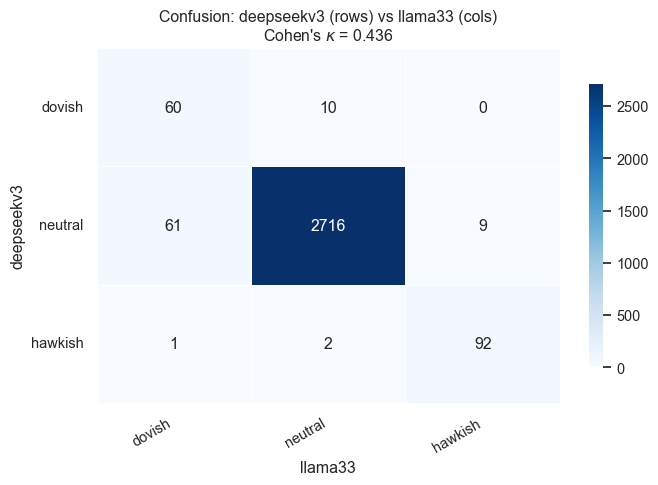

In [34]:
# 1h. Confusion heatmap for the most-divergent model pair
worst = pairwise_df.iloc[-1]  # lowest κ (df is sorted descending)
m_a, m_b = worst["model_a"], worst["model_b"]
kappa_val = worst["Cohen's κ"]

# Keep only rows where both models gave a valid (non-parse_error) label
valid = wide[[m_a, m_b]].dropna()
valid = valid[valid[m_a].isin(LABEL_ORDER) & valid[m_b].isin(LABEL_ORDER)]

cm = pd.crosstab(
    pd.Categorical(valid[m_a], categories=LABEL_ORDER, ordered=True),
    pd.Categorical(valid[m_b], categories=LABEL_ORDER, ordered=True),
    rownames=[m_a],
    colnames=[m_b],
)

title = f"Confusion: {m_a} (rows) vs {m_b} (cols)\nCohen's " + r"$\kappa$" + f" = {kappa_val:.3f}"

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", linewidths=0.4,
    ax=ax, cbar_kws={"shrink": 0.8},
)
ax.set_title(title)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "llm_confusion_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

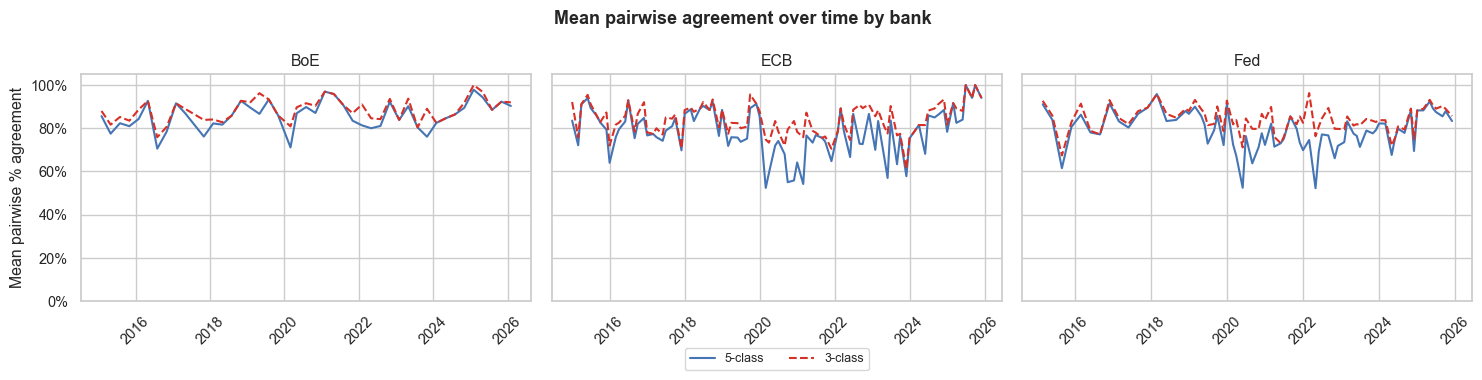

In [38]:
import matplotlib.ticker as mticker

# 3-class collapse map (hawk/neutral/dove)
COLLAPSE3 = {
    "hawkish": "hawk", "mostly hawkish": "hawk",
    "neutral": "neutral",
    "dovish": "dove", "mostly dovish": "dove",
}

all_pairs = list(combinations(MODELS, 2))

# 5-class exact agreement
wide["mean_pairwise_agree"] = pd.concat(
    [(wide[a] == wide[b]).astype(float) for a, b in all_pairs], axis=1
).mean(axis=1)

# 3-class exact agreement
for m in MODELS:
    wide[f"{m}_3"] = wide[m].map(COLLAPSE3)

wide["mean_pairwise_agree3"] = pd.concat(
    [(wide[f"{a}_3"] == wide[f"{b}_3"]).astype(float) for a, b in all_pairs], axis=1
).mean(axis=1)

ts_agree = (
    wide.groupby(["bank", "date_dt"])
    .agg(
        agree5=("mean_pairwise_agree", "mean"),
        agree3=("mean_pairwise_agree3", "mean"),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, bank in zip(axes, BANKS):
    sub = ts_agree[ts_agree["bank"] == bank].sort_values("date_dt")
    ax.plot(sub["date_dt"], sub["agree5"], linewidth=1.5, label="5-class", color="#4575b4")
    ax.plot(sub["date_dt"], sub["agree3"], linewidth=1.5, label="3-class", color="#d73027", linestyle="--")
    ax.set_title(bank)
    ax.set_xlabel("")
    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

axes[0].set_ylabel("Mean pairwise % agreement")
axes[1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=2, fontsize=9)
fig.suptitle("Mean pairwise agreement over time by bank", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


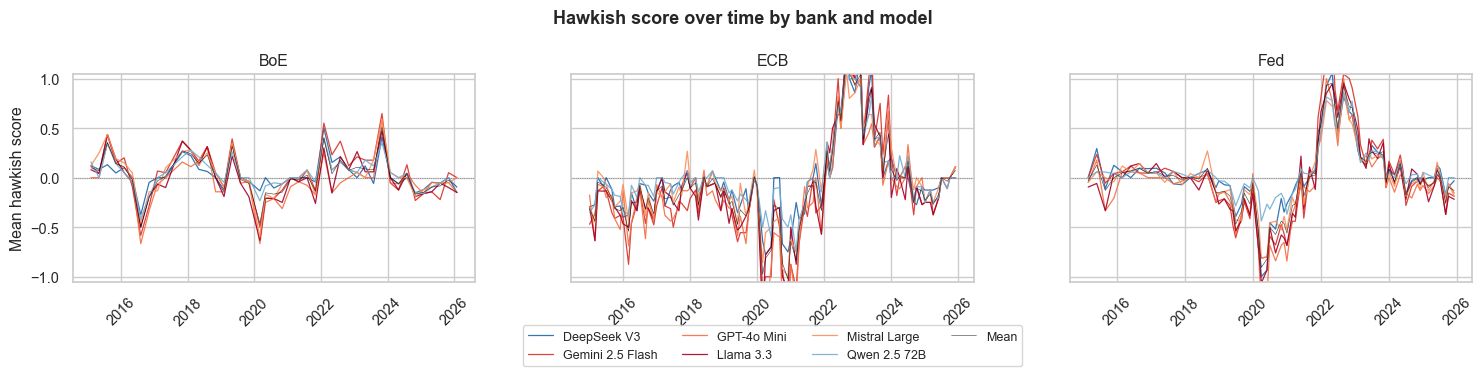

In [ ]:
# Hawkish score over time by model, grouped by neutral bias
HEAVY_NEUTRAL = ["deepseekv3", "qwen25_72b"]
OTHERS = [m for m in MODELS if m not in HEAVY_NEUTRAL]

MODEL_COLORS = {
    "deepseekv3":      "#2166ac",
    "qwen25_72b":      "#74add1",
    "gemini25flash":   "#d73027",
    "gpt-4o":          "#f46d43",
    "llama33":         "#a50026",
    "mistrallarge_or": "#fc8d59",
}

ts_hawk = (
    raw.groupby(["bank", "date_dt", "model_key"])["hawk_score"]
    .mean()
    .reset_index()
)

ts_mean = (
    raw.groupby(["bank", "date_dt"])["hawk_score"]
    .mean()
    .reset_index()
    .rename(columns={"hawk_score": "mean_score"})
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, bank in zip(axes, BANKS):
    for model in MODELS:
        sub = ts_hawk[(ts_hawk["bank"] == bank) & (ts_hawk["model_key"] == model)].sort_values("date_dt")
        ax.plot(sub["date_dt"], sub["hawk_score"],
                color=MODEL_COLORS[model],
                linewidth=0.9, alpha=0.9,
                label=MODEL_LABELS[model])

    mean_sub = ts_mean[ts_mean["bank"] == bank].sort_values("date_dt")
    ax.plot(mean_sub["date_dt"], mean_sub["mean_score"],
            color="black", linewidth=0.4, alpha=0.8, label="Mean", zorder=5)

    ax.axhline(0, color="black", linewidth=0.6, linestyle=":", alpha=0.4)
    ax.set_title(bank)
    ax.set_ylim(-1, 1)
    ax.set_ylim(-1.05, 1.1)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

axes[0].set_ylabel("Mean hawkish score")
axes[1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=4, fontsize=9)
fig.suptitle("Hawkish score over time by bank and model", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


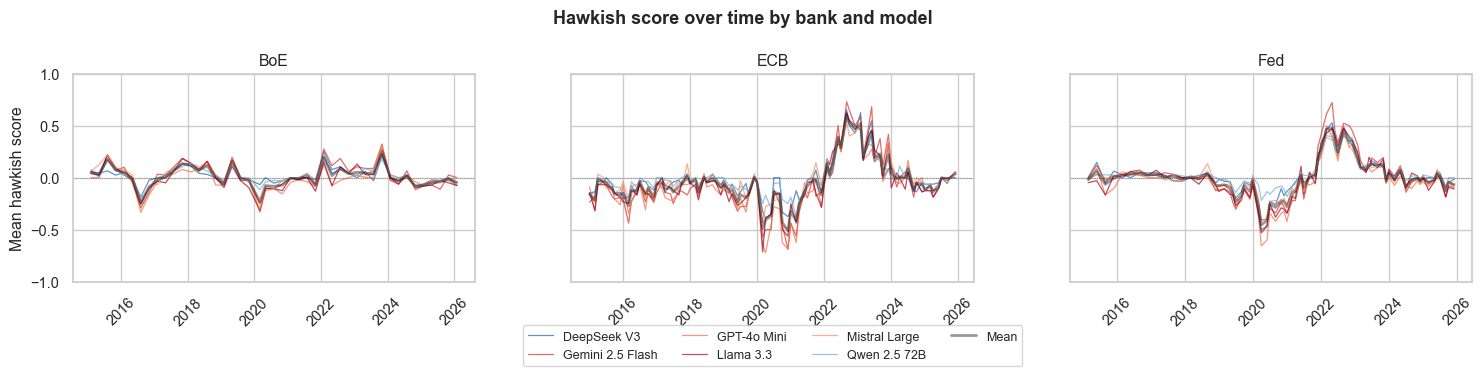

In [54]:
# Hawkish score over time by model, grouped by neutral bias
HEAVY_NEUTRAL = ["deepseekv3", "qwen25_72b"]
OTHERS = [m for m in MODELS if m not in HEAVY_NEUTRAL]

MODEL_COLORS = {
    "deepseekv3":      "#2166ac",
    "qwen25_72b":      "#74add1",
    "gemini25flash":   "#d73027",
    "gpt-4o":          "#f46d43",
    "llama33":         "#a50026",
    "mistrallarge_or": "#fc8d59",
}

ts_hawk = (
    raw.groupby(["bank", "date_dt", "model_key"])["hawk_score"]
    .mean()
    .reset_index()
)
ts_hawk["hawk_score"] = ts_hawk["hawk_score"] / 2

ts_mean = (
    raw.groupby(["bank", "date_dt"])["hawk_score"]
    .mean()
    .reset_index()
    .rename(columns={"hawk_score": "mean_score"})
)
ts_mean["mean_score"] = ts_mean["mean_score"] / 2

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, bank in zip(axes, BANKS):
    for model in MODELS:
        sub = ts_hawk[(ts_hawk["bank"] == bank) & (ts_hawk["model_key"] == model)].sort_values("date_dt")
        ax.plot(sub["date_dt"], sub["hawk_score"],
                color=MODEL_COLORS[model],
                linewidth=0.9, alpha=0.7,
                label=MODEL_LABELS[model])

    mean_sub = ts_mean[ts_mean["bank"] == bank].sort_values("date_dt")
    ax.plot(mean_sub["date_dt"], mean_sub["mean_score"],
            color="black", linewidth=2.0, alpha=0.4, label="Mean", zorder=5)

    ax.axhline(0, color="black", linewidth=0.6, linestyle=":", alpha=0.4)
    ax.set_title(bank)
    ax.set_ylim(-1, 1)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

axes[0].set_ylabel("Mean hawkish score")
axes[1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=4, fontsize=9)
fig.suptitle("Hawkish score over time by bank and model", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


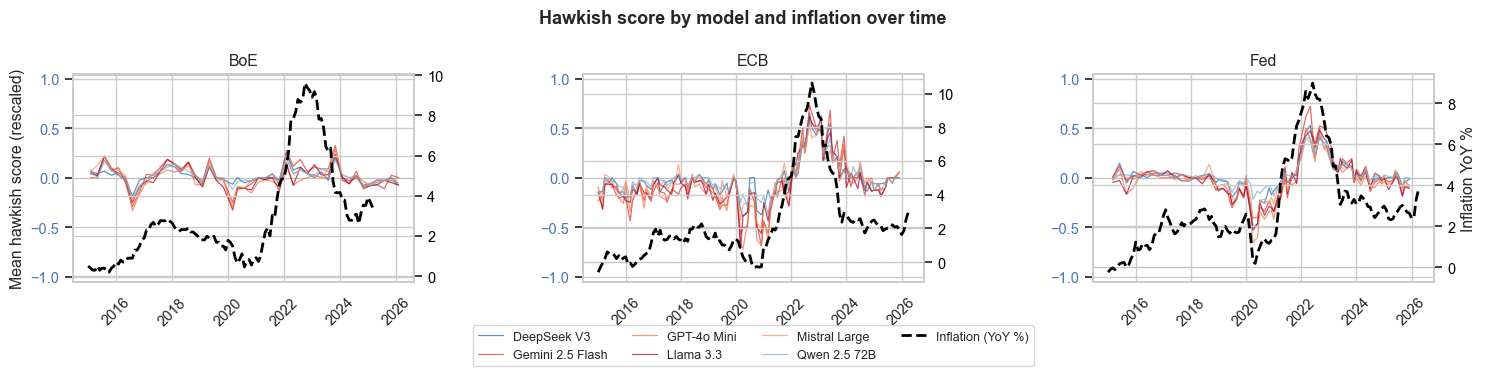

In [56]:
import matplotlib.ticker as mticker

# Load and compute YoY inflation for each bank
def load_yoy(path, bank_label):
    df = pd.read_csv(path)
    df["date_dt"] = pd.to_datetime(df["Observation_Month"])
    df = df.sort_values("date_dt").reset_index(drop=True)
    df["yoy"] = df["Current_Value"].pct_change(12) * 100  # Current_Value not Initial_Value
    df["bank"] = bank_label
    return df[["bank", "date_dt", "yoy"]].dropna()


infl = pd.concat([
    load_yoy(r"../data/controls/us_cpi_vintages.csv",  "Fed"),
    load_yoy(r"../data/controls/uk_cpi_vintages.csv",  "BoE"),
    load_yoy(r"../data/controls/ez_hicp_vintages.csv", "ECB"),
], ignore_index=True)

# Recompute ts_hawk rescaled to [-1, 1]
HEAVY_NEUTRAL = ["deepseekv3", "qwen25_72b"]
MODEL_COLORS = {
    "deepseekv3":      "#2166ac",
    "qwen25_72b":      "#74add1",
    "gemini25flash":   "#d73027",
    "gpt-4o":          "#f46d43",
    "llama33":         "#a50026",
    "mistrallarge_or": "#fc8d59",
}

ts_hawk = (
    raw.groupby(["bank", "date_dt", "model_key"])["hawk_score"]
    .mean()
    .reset_index()
)
ts_hawk["hawk_score"] = ts_hawk["hawk_score"] / 2

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, bank in zip(axes, BANKS):
    ax2 = ax.twinx()

    # Per-model hawkish scores
    for model in MODELS:
        sub = ts_hawk[(ts_hawk["bank"] == bank) & (ts_hawk["model_key"] == model)].sort_values("date_dt")
        ax.plot(sub["date_dt"], sub["hawk_score"],
                color=MODEL_COLORS[model], linewidth=0.9, alpha=0.7,
                label=MODEL_LABELS[model])

    # Inflation on right axis
    infl_sub = infl[infl["bank"] == bank].sort_values("date_dt")
    ax2.plot(infl_sub["date_dt"], infl_sub["yoy"],
             color="black", linewidth=2.0, linestyle="--", label="Inflation (YoY %)", zorder=5)

    ax.axhline(0, color="grey", linewidth=0.6, linestyle=":", alpha=0.4)
    ax2.axhline(0, color="grey", linewidth=0.4, linestyle=":", alpha=0.3)

    ax.set_title(bank)
    ax.set_ylim(-1.05, 1.05)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))
    ax.tick_params(axis="y", labelcolor="#4575b4")

    ax2.set_ylabel("Inflation YoY %" if bank == "Fed" else "")
    ax2.tick_params(axis="y", labelcolor="black")

    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

axes[0].set_ylabel("Mean hawkish score (rescaled)")

# Combined legend in middle panel
lines1, labels1 = axes[1].get_legend_handles_labels()
ax2_mid = axes[1].get_shared_x_axes()
lines2 = [plt.Line2D([0], [0], color="black", linewidth=2, linestyle="--")]
labels2 = ["Inflation (YoY %)"]
axes[1].legend(lines1 + lines2, labels1 + labels2,
               loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=4, fontsize=9)

fig.suptitle("Hawkish score by model and inflation over time", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


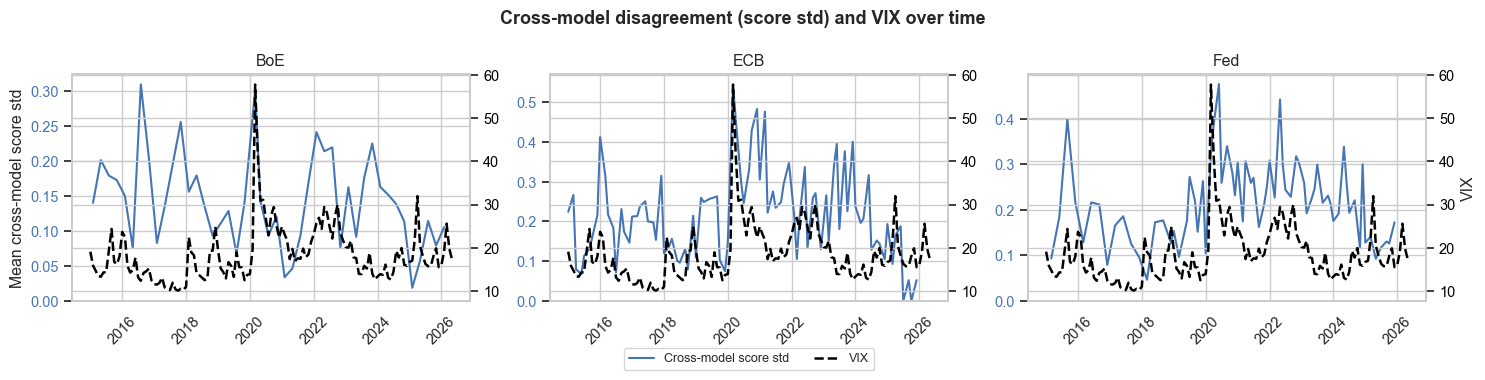

In [58]:
# Score std vs VIX over time by bank
vix = pd.read_csv("../data/controls/vix_daily.csv")
vix["date_dt"] = pd.to_datetime(vix["Date"])
vix_monthly = (
    vix.set_index("date_dt")["VIX"]
    .resample("MS").mean()
    .reset_index()
)

ts_std = (
    wide.groupby(["bank", "date_dt"])
    .agg(mean_score_std=("score_std", "mean"))
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, bank in zip(axes, BANKS):
    ax2 = ax.twinx()

    sub = ts_std[ts_std["bank"] == bank].sort_values("date_dt")
    ax.plot(sub["date_dt"], sub["mean_score_std"],
            color="#4575b4", linewidth=1.5, label="Score std")

    ax2.plot(vix_monthly["date_dt"], vix_monthly["VIX"],
             color="black", linewidth=1.8, linestyle="--", label="VIX", zorder=5)

    ax.set_title(bank)
    ax.set_ylim(0, ax.get_ylim()[1])
    ax.tick_params(axis="y", labelcolor="#4575b4")
    ax2.tick_params(axis="y", labelcolor="black")
    ax2.set_ylabel("VIX" if bank == "Fed" else "")

    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

axes[0].set_ylabel("Mean cross-model score std")

lines = [plt.Line2D([0], [0], color="#4575b4", linewidth=1.5),
         plt.Line2D([0], [0], color="black", linewidth=1.8, linestyle="--")]
axes[1].legend(lines, ["Cross-model score std", "VIX"],
               loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=2, fontsize=9)

fig.suptitle("Cross-model disagreement (score std) and VIX over time", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


In [62]:
from scipy.stats import pearsonr, spearmanr

# Merge score_std and VIX on date
corr_rows = []
for bank in BANKS:
    sub = ts_std[ts_std["bank"] == bank].sort_values("date_dt")
    
    merged = sub.merge(vix_monthly, on="date_dt", how="inner").dropna()

    p_r, p_p = pearsonr(merged["mean_score_std"], merged["VIX"])
    s_r, s_p = spearmanr(merged["mean_score_std"], merged["VIX"])
    corr_rows.append({
        "Bank": bank,
        "Pearson r": round(p_r, 3),
        "Pearson p": round(p_p, 3),
        "Spearman r": round(s_r, 3),
        "Spearman p": round(s_p, 3),
        "N months": len(merged),
    })

corr_df = pd.DataFrame(corr_rows)
print(corr_df.to_string(index=False))


Bank  Pearson r  Pearson p  Spearman r  Spearman p  N months
 BoE      0.210       0.17      -0.128       0.406        44
 ECB      0.425       0.00       0.232       0.030        88
 Fed      0.512       0.00       0.416       0.000        72


## 5. Agreement vs. Confidence

Each model self-reports a confidence (low/medium/high). Do the models agree more on turns they collectively rate high-confidence? A strong negative relationship between mean confidence and disagreement width would mean confidence is a usable proxy for label reliability.

In [ ]:
# 4. Agreement vs. confidence — do models agree more on turns they rate high-confidence?
for m in MODELS:
    wide[f"{m}_confs"] = wide[f"{m}_conf"].map(CONF_SCORE)
wide["mean_conf"] = wide[[f"{m}_confs" for m in MODELS]].mean(axis=1)

wide["conf_bin"] = pd.cut(wide["mean_conf"], bins=[0, 1.5, 2.0, 2.5, 3.01],
                          labels=["≤1.5", "1.5–2.0", "2.0–2.5", ">2.5"])
agg = wide.groupby("conf_bin", observed=True).agg(
    n=("all_agree", "size"),
    pct_agree=("all_agree", "mean"),
    mean_width=("disagree_width", "mean"),
    mean_entropy=("label_entropy", "mean"),
)
print("Agreement by mean-confidence bin:")
display(agg.style.format({"pct_agree": "{:.1%}", "mean_width": "{:.2f}", "mean_entropy": "{:.3f}"}))

rho = spearmanr(wide["mean_conf"], wide["disagree_width"], nan_policy="omit").correlation
print(f"\nSpearman(mean_conf, disagree_width) = {rho:.3f}  "
      f"(negative ⇒ more confident → less disagreement)")

fig, ax = plt.subplots(figsize=(7, 4))
agg["pct_agree"].plot(kind="bar", ax=ax, color="steelblue", width=0.7, edgecolor="white")
ax.set_ylabel(f"% exact {len(MODELS)}-way agreement")
ax.set_xlabel("mean confidence across models")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.set_title("Do models agree more when individually confident?")
plt.setp(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "llm_agreement_vs_confidence.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Hawk Score Over Time

Average stance score per meeting, one line per model, one panel per bank.

In [ ]:
ts_hawk = (
    raw
    .groupby(["bank", "date_dt", "model_key"])["hawk_score"]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

for ax, bank in zip(axes, BANKS):
    bdf = ts_hawk[ts_hawk["bank"] == bank]
    for model in MODELS:
        mdf = bdf[bdf["model_key"] == model].sort_values("date_dt")
        ax.plot(
            mdf["date_dt"], mdf["hawk_score"],
            label=MODEL_LABELS[model], color=MODEL_COLORS[model],
            linewidth=1.4, marker="o", markersize=3, alpha=0.85,
        )
    ax.axhline(0, color="black", linestyle="--", linewidth=0.7, alpha=0.5)
    ax.set_title(BANK_TITLES[bank], fontsize=11)
    ax.set_xlabel("Meeting date")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")
    ax.set_ylim(-2.3, 2.3)
    ax.set_yticks([-2, -1, 0, 1, 2])
    ax.set_yticklabels(["dovish", "m. dovish", "neutral", "m. hawkish", "hawkish"], fontsize=7)

axes[0].set_ylabel("Mean stance score")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center", ncol=6, fontsize=9,
    bbox_to_anchor=(0.5, -0.12), frameon=True,
)
fig.suptitle("Average hawkish score by meeting — per model", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "timeseries_hawk_score_by_model.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Disagreement Over Time (three measures)

Per-meeting disagreement using binary (% turns not unanimous), label entropy (nominal), and score SD (ordinal dispersion). Peaks should cluster on high-uncertainty meetings.

In [ ]:
# Disagreement over time — three measures per meeting: binary, entropy, score-SD
ts = (
    wide.groupby(["bank", "date_dt"]).agg(
        binary=("all_agree", lambda s: 1 - s.mean()),
        entropy=("label_entropy", "mean"),
        score_std=("score_std", "mean"),
    ).reset_index()
)

bank_colors = {"BoE": "#e377c2", "ECB": "#17becf", "Fed": "#bcbd22"}
methods = [
    ("binary",    "% turns not unanimous"),
    ("entropy",   "mean label entropy"),
    ("score_std", "mean score SD (dispersion)"),
]

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
for ax, (col, ylab) in zip(axes, methods):
    for bank in BANKS:
        bdf = ts[ts["bank"] == bank].sort_values("date_dt")
        ax.plot(bdf["date_dt"], bdf[col], label=BANK_TITLES[bank],
                color=bank_colors[bank], linewidth=1.3, marker="o", markersize=2.5, alpha=0.85)
    ax.set_ylabel(ylab)
    ax.set_title(f"Disagreement over time — {col}", fontsize=10, loc="left")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
axes[0].set_ylim(0, 1)
axes[0].legend(ncol=3, fontsize=8)
axes[-1].set_xlabel("Meeting date")
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "timeseries_disagreement_3methods.png", dpi=150, bbox_inches="tight")
plt.show()

print("Mean disagreement per bank (three measures):")
display(ts.groupby("bank")[["binary", "entropy", "score_std"]].mean().round(3))

## 8. Confidence Over Time

Average self-reported confidence per meeting, one line per model, one panel per bank.

In [ ]:
ts_conf = (
    raw
    .groupby(["bank", "date_dt", "model_key"])["conf_score"]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

for ax, bank in zip(axes, BANKS):
    bdf = ts_conf[ts_conf["bank"] == bank]
    for model in MODELS:
        mdf = bdf[bdf["model_key"] == model].sort_values("date_dt")
        ax.plot(
            mdf["date_dt"], mdf["conf_score"],
            label=MODEL_LABELS[model], color=MODEL_COLORS[model],
            linewidth=1.4, marker="o", markersize=3, alpha=0.85,
        )
    ax.set_title(BANK_TITLES[bank], fontsize=11)
    ax.set_xlabel("Meeting date")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")
    ax.set_ylim(0.8, 3.2)
    ax.set_yticks([1, 2, 3])
    ax.set_yticklabels(["low", "medium", "high"])

axes[0].set_ylabel("Mean confidence")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center", ncol=6, fontsize=9,
    bbox_to_anchor=(0.5, -0.12), frameon=True,
)
fig.suptitle("Average model confidence by meeting", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "timeseries_confidence_by_model.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Ensemble Stance Series

Mean stance across the 6 models per meeting, with a +/-1 cross-model SD dispersion band. Exported as `ensemble_stance_meeting.csv` for the downstream spillover VAR.

In [ ]:
# 9. Ensemble stance series — mean across 6 models per meeting + cross-model dispersion band
ens = (
    wide.groupby(["bank", "date_dt"]).agg(
        mean_stance=("mean_score", "mean"),
        dispersion=("score_std", "mean"),
        n_turns=("turn_uid", "size"),
    ).reset_index().sort_values(["bank", "date_dt"])
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, bank in zip(axes, BANKS):
    bdf = ens[ens["bank"] == bank]
    ax.plot(bdf["date_dt"], bdf["mean_stance"], color="black", linewidth=1.5)
    ax.fill_between(bdf["date_dt"], bdf["mean_stance"] - bdf["dispersion"],
                    bdf["mean_stance"] + bdf["dispersion"], alpha=0.2, color="steelblue")
    ax.axhline(0, color="grey", linestyle="--", linewidth=0.7)
    ax.set_title(BANK_TITLES[bank]); ax.set_ylim(-2, 2)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")
axes[0].set_ylabel("ensemble mean stance (±1 cross-model SD)")
fig.suptitle("Ensemble stance series (mean of 6 models) — candidate VAR input", y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "ensemble_stance_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()

ens.to_csv(OUTPUT_DIR / "ensemble_stance_meeting.csv", index=False)
print(f"Saved {OUTPUT_DIR / 'ensemble_stance_meeting.csv'}  ({len(ens)} bank-meetings)")
display(ens.head())